# EDA


In [2]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)

train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

train.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


### Баланс таргета

In [2]:
train['Transported'].value_counts(normalize=True).round(4)

Transported
True     0.5036
False    0.4964
Name: proportion, dtype: float64

Классы сбалансированы, не нужно дальше это учитывать


### Анализ пропусков


In [3]:
train.isna().sum().sort_values()

PassengerId       0
Transported       0
Age             179
RoomService     181
Destination     182
FoodCourt       183
Spa             183
VRDeck          188
Cabin           199
Name            200
HomePlanet      201
VIP             203
ShoppingMall    208
CryoSleep       217
dtype: int64

In [4]:
miss_cols = ['HomePlanet','CryoSleep','Cabin','Destination','Age','VIP',
             'RoomService','FoodCourt','ShoppingMall','Spa','VRDeck','Name']
miss_counts = train[miss_cols].isna().sum().sort_values()
miss_per_row = train[miss_cols].isna().sum(axis=1)
np.round((miss_per_row == 1).sum() / len(train), 2), np.round((miss_per_row > 1).sum() / len(train), 2)

(np.float64(0.21), np.float64(0.03))

Очень большая доля строк, где есть 1 пропуск. Удалить их не получится, иначе потеряем много данных. Нужно заполнять пропуски

### CryoSleep и траты на удобства

Попробуем предположить, что пассажир в криосне физически не может
тратить деньги на рестораны/спа. Если гипотеза подтвердится — это отличный способ восстанавливать пропуски в
`CryoSleep` через траты и наоборот

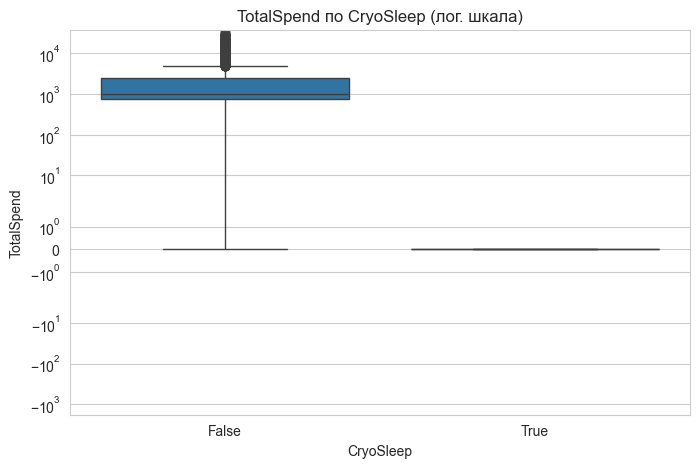

In [6]:
spend_cols = ['RoomService','FoodCourt','ShoppingMall','Spa','VRDeck']
train['TotalSpend'] = train[spend_cols].sum(axis=1, skipna=True)

sub = train.dropna(subset=['CryoSleep'])

plt.figure(figsize=(8, 5))
sns.boxplot(data=sub, x='CryoSleep', y='TotalSpend')
plt.yscale('symlog')
plt.title('TotalSpend по CryoSleep (лог. шкала)')
plt.show()

Гипотеза подтвердилась. У пассажиров с `CryoSleep=True` сумма трат около 0.

### Распределение трат по категориям


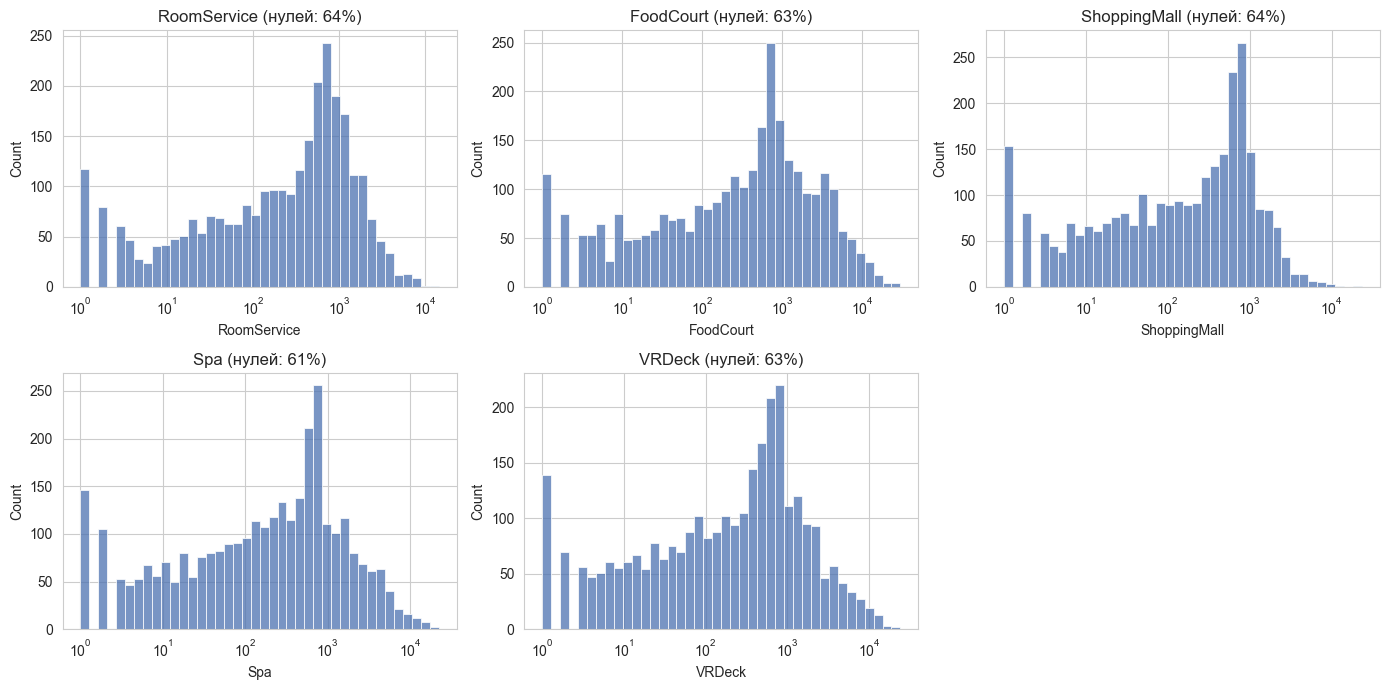

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()

for i, c in enumerate(spend_cols):
    zero_share = (train[c] == 0).mean()
    sns.histplot(train[train[c] > 0][c], bins=40, log_scale=True, ax=axes[i], color='#4C72B0')
    axes[i].set_title(f'{c} (нулей: {zero_share:.0%})')

axes[5].axis('off')
plt.tight_layout()
plt.show()

Во всех 5 категориях трат 61-64% значений — нули. Также сильно отличается порядок трат, что даст нам большие значения разбора. Для линейных моделей попробуем логарифмировать, плюс имеет смысл осздать бинарный признак HasSpent_X.

### Cabin: Deck и Side

Разбираем `Cabin` на `Deck/CabinNum/Side`, смотрим на связь с `HomePlanet` и с таргетом.

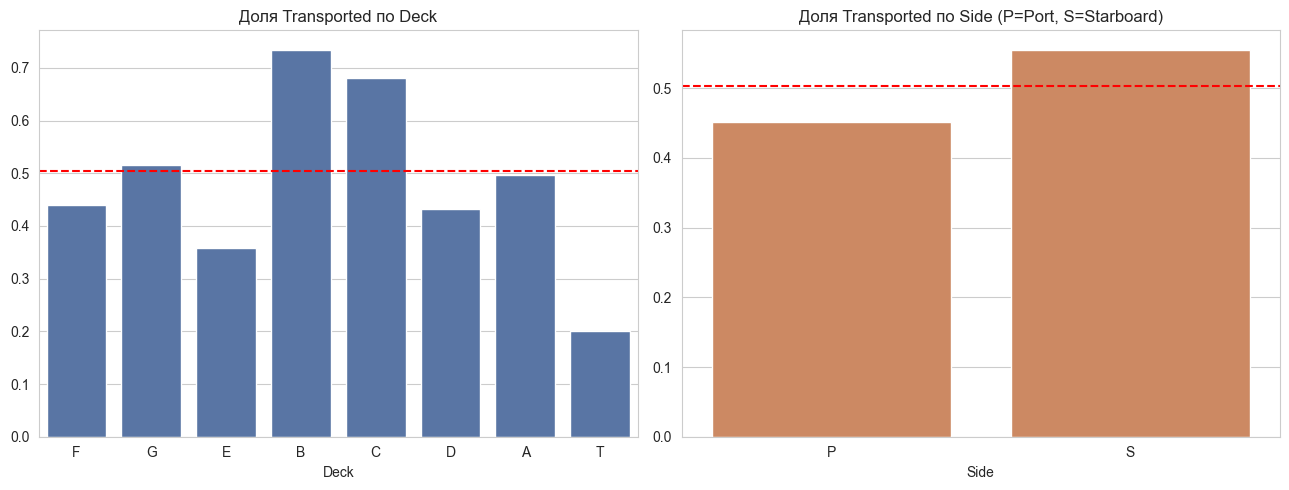

HomePlanet,Earth,Europa,Mars
Deck,,,
A,0,252,0
B,0,766,0
C,0,734,0
D,0,186,282
E,395,128,330
F,1614,0,1110
G,2498,0,0
T,0,4,0


In [8]:
cabin_split = train['Cabin'].str.split('/', expand=True)
train['Deck'] = cabin_split[0]
train['CabinNum'] = cabin_split[1].astype(float)
train['Side'] = cabin_split[2]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

deck_order = train['Deck'].value_counts().index
sns.barplot(x=train.groupby('Deck')['Transported'].mean().reindex(deck_order).index,
            y=train.groupby('Deck')['Transported'].mean().reindex(deck_order).values,
            ax=axes[0], color='#4C72B0')
axes[0].axhline(train['Transported'].mean(), color='red', linestyle='--')
axes[0].set_title('Доля Transported по Deck')

sns.barplot(x=train.groupby('Side')['Transported'].mean().index,
            y=train.groupby('Side')['Transported'].mean().values,
            ax=axes[1], color='#DD8452')
axes[1].axhline(train['Transported'].mean(), color='red', linestyle='--')
axes[1].set_title('Доля Transported по Side (P=Port, S=Starboard)')

plt.tight_layout()
plt.show()

pd.crosstab(train['Deck'], train['HomePlanet'])

70% на Deck B против 20-35% на Deck T/E, Deck неплохую связть дает с HomePlanet (A/B/C/T — только Europa, G — только Earth) — можно восстанавливать пропуски друг через друга.

### Группы пассажиров

`PassengerId` = `gggg_pp`, `gggg` — номер группы. Проверяем размер группы и однородность `HomePlanet` внутри группы.

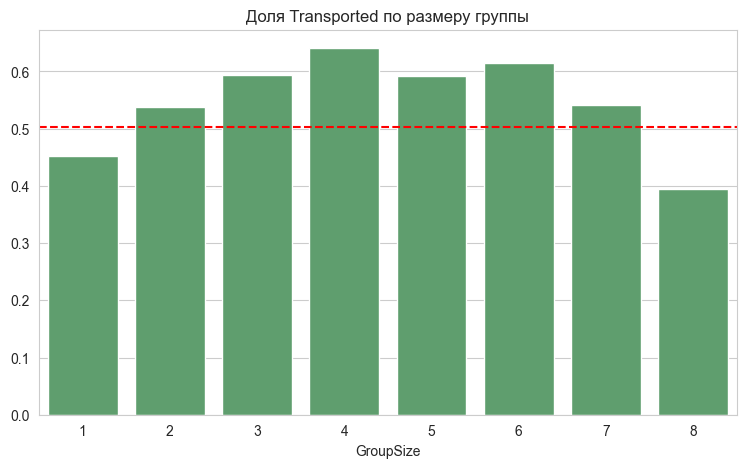

np.float64(0.0)

In [9]:
train['GroupId'] = train['PassengerId'].str.split('_').str[0]
group_sizes = train.groupby('GroupId').size()
train['GroupSize'] = train['GroupId'].map(group_sizes)

rate_by_size = train.groupby('GroupSize')['Transported'].mean()
sns.barplot(x=rate_by_size.index, y=rate_by_size.values, color='#55A868')
plt.axhline(train['Transported'].mean(), color='red', linestyle='--')
plt.title('Доля Transported по размеру группы')
plt.show()

homeplanet_known = train.dropna(subset=['HomePlanet'])
nunique_per_group = homeplanet_known.groupby('GroupId')['HomePlanet'].nunique()
(nunique_per_group > 1).mean()

Одиночки (GroupSize=1, больше половины train) переносятся реже среднего (45%), группы 3-6 человек — чаще (59-64%), GroupSize/IsAlone стоит добавить. Разных HomePlanet внутри одной группы не встречается ни разу — пропуски в HomePlanet можно восстанавливать модой по группе.

### Возраст

Смотрим распределение и есть ли эффект для детей.

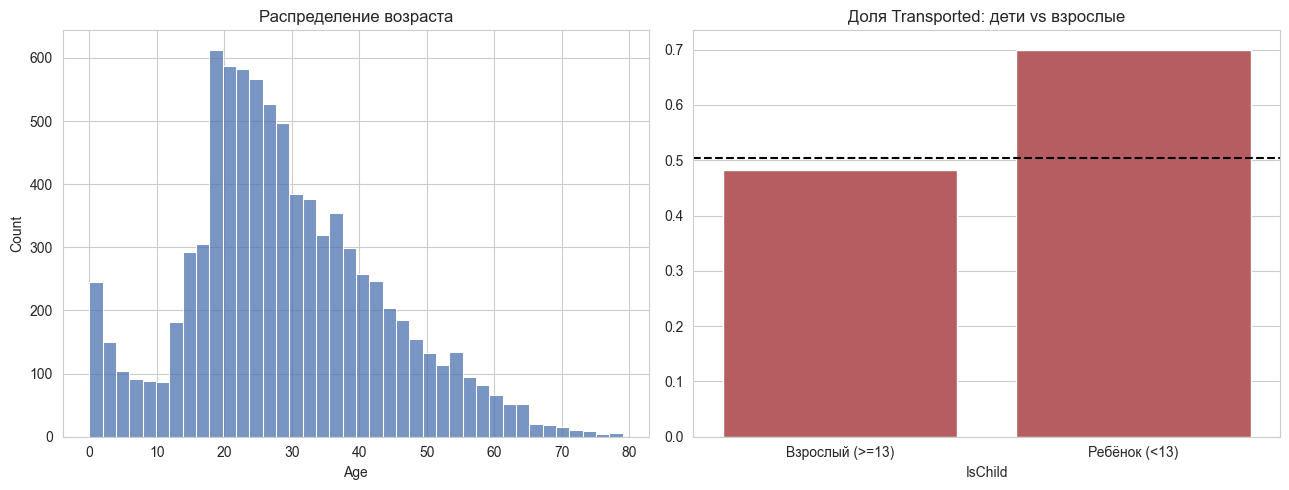

IsChild
False    0.483134
True     0.699752
Name: Transported, dtype: float64

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(train['Age'].dropna(), bins=40, ax=axes[0], color='#4C72B0')
axes[0].set_title('Распределение возраста')

train['IsChild'] = train['Age'] < 13
rate_by_child = train.dropna(subset=['Age']).groupby('IsChild')['Transported'].mean()
sns.barplot(x=rate_by_child.index.map({True: 'Ребёнок (<13)', False: 'Взрослый (>=13)'}),
            y=rate_by_child.values, ax=axes[1], color='#C44E52')
axes[1].axhline(train['Transported'].mean(), color='black', linestyle='--')
axes[1].set_title('Доля Transported: дети vs взрослые')

plt.tight_layout()
plt.show()

rate_by_child

In [11]:
train['Age'].min(), train['Age'].max()

(np.float64(0.0), np.float64(79.0))

Возраст в разумном диапазоне 0-79, аномалий нет. Дети до 13 лет переносятся значительно чаще (70%) взрослых (48%) — IsChild явно стоит добавить.

### HomePlanet, Destination, VIP

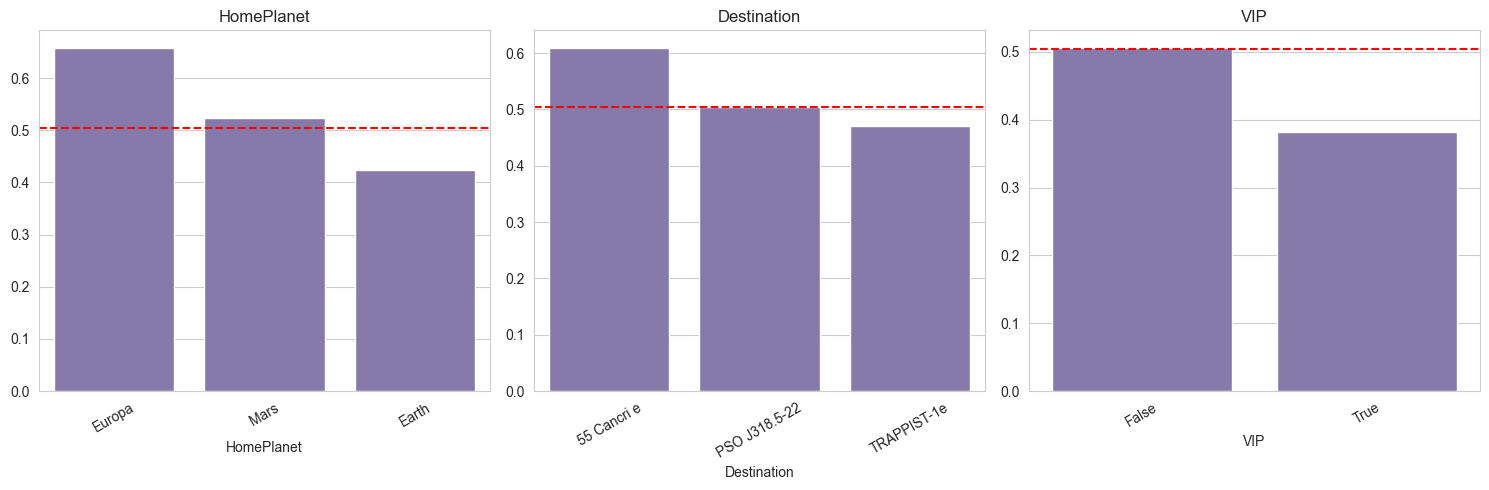

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col in zip(axes, ['HomePlanet', 'Destination', 'VIP']):
    rate = train.dropna(subset=[col]).groupby(col)['Transported'].mean().sort_values(ascending=False)
    sns.barplot(x=rate.index, y=rate.values, ax=ax, color='#8172B2')
    ax.axhline(train['Transported'].mean(), color='red', linestyle='--')
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

Europa заметно выше среднего (66%), Earth — ниже (42%). Destination даёт более скромный разброс. VIP переносятся реже (38% vs 51%)

### Корреляция числовых признаков

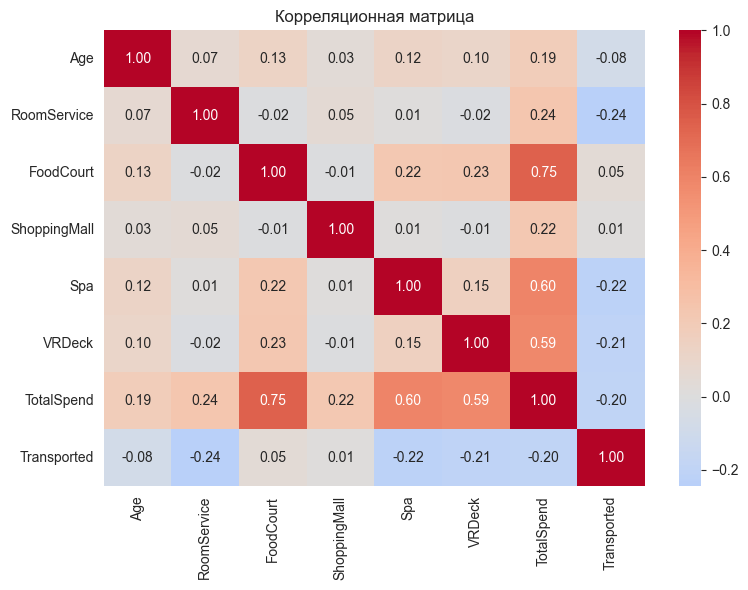

In [13]:
num_for_corr = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'TotalSpend']
corr_df = train[num_for_corr + ['Transported']].copy()
corr_df['Transported'] = corr_df['Transported'].astype(int)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Корреляционная матрица')
plt.tight_layout()
plt.show()

Сильных линейных связей с таргетом нет.

### Что берём в Feature Engineering

- `CryoSleep` ↔ `TotalSpend` — взаимная импутация
- `Deck` ↔ `HomePlanet` — связь четко прослеживается
- `GroupId` ↔ `HomePlanet` — состав группы однороден по планете
- `Deck`, `Side` — берем обязательно
- `GroupSize` / `IsAlone`
- `IsChild` (Age < 13)
- log для трат, бинарные `HasSpent_*`
- импутация по колонкам